# OptiCrop – Smart Agricultural Production Optimization Engine
## Crop Model Training Notebook

This notebook performs:
1. Data loading and EDA (missing values, correlation, heatmaps, distributions, feature importance, crop distribution)
2. Preprocessing (missing value handling, feature scaling, label encoding)
3. Model training and comparison (Decision Tree, Random Forest, Logistic Regression, KNN, K-Means Clustering)
4. Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix, Classification Report)
5. Saving the best model, scaler, and label encoder

**SmartBridge Virtual Internship Project**

### 1. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_SEED = 42
print('Libraries imported successfully.')

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


### 2. Load Dataset

In [2]:
df = pd.read_csv('../dataset/Crop_recommendation.csv')
df.head()

,label,N,P,K,temperature,humidity,ph,rainfall
0,rice,93.05,31.68,47.25,24.88,72.24,5.35,213.84
1,rice,86.84,39.87,36.03,24.76,85.89,6.03,243.82
2,rice,94.68,33.13,44.58,21.08,86.39,5.98,204.45
3,rice,83.19,49.78,40.92,22.14,80.24,6.27,220.96
4,rice,94.13,43.45,56.99,22.19,79.44,5.59,228.48


In [3]:
print('Dataset shape:', df.shape)
print('\nData types:\n', df.dtypes)
print('\nSummary statistics:\n', df.describe())

Dataset shape: (2200, 8)

Data types:
 label              str
N              float64
P              float64
K              float64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
dtype: object

Summary statistics:
                  N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     54.045491    53.041236    43.367136    25.860345    69.653827   
std      37.785160    32.507646    52.323300     3.839330    12.541542   
min       4.400000     4.350000     1.380000    15.450000    29.760000   
25%      24.202500    24.122500    18.000000    23.120000    61.020000   
50%      31.760000    50.995000    22.650000    25.780000    68.550000   
75%      89.370000    67.005000    42.895000    28.890000    79.767500   
max     155.500000   161.150000   236.360000    36.050000   100.000000   

                ph     rainfall  
count  2200.000000  2200.000000  
mean  

### 3. Exploratory Data Analysis (EDA)

#### 3.1 Missing Values

Missing values per column:
 label          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
dtype: int64


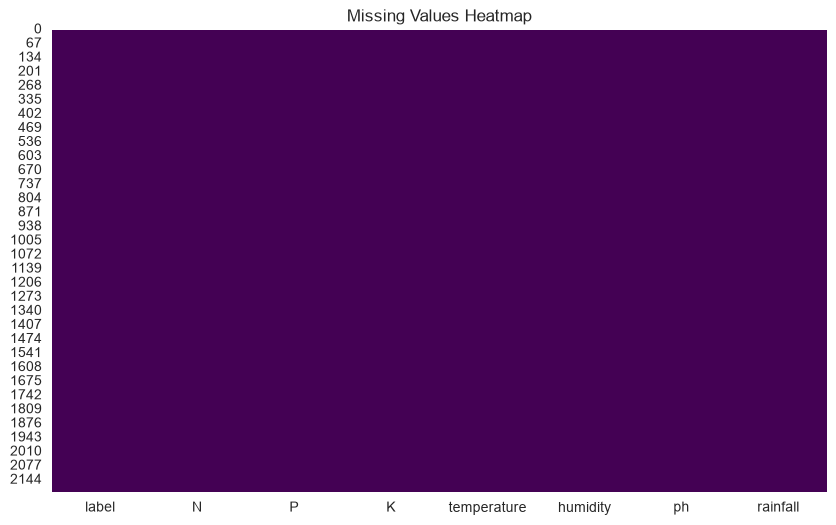

In [4]:
print('Missing values per column:\n', df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

#### 3.2 Correlation Matrix & Heatmap

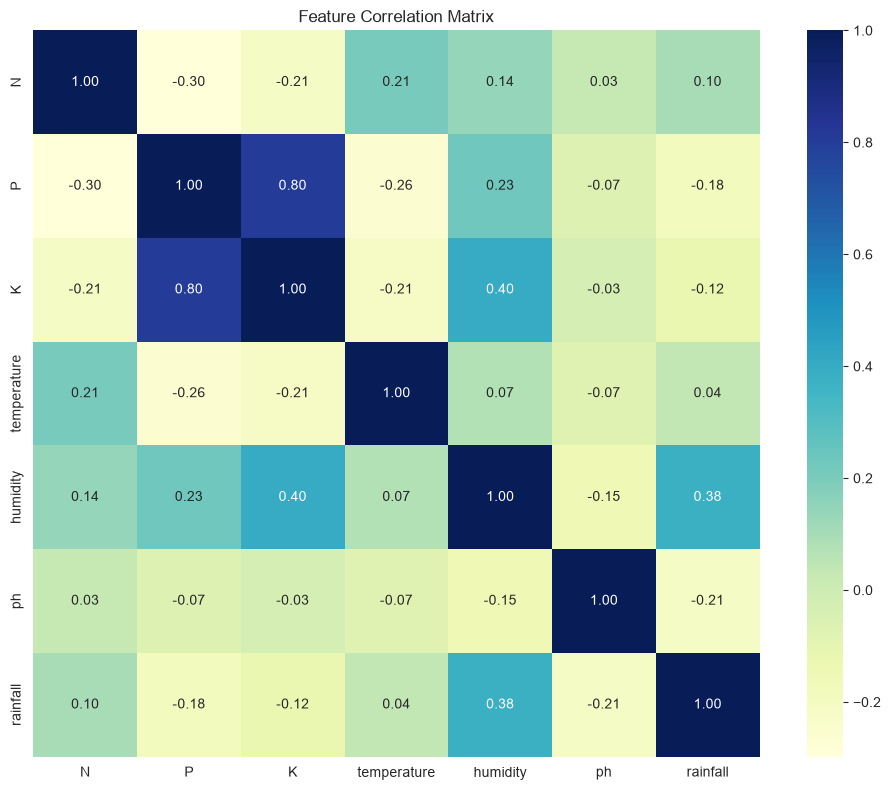

In [5]:
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
corr = df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

#### 3.3 Distribution Graphs

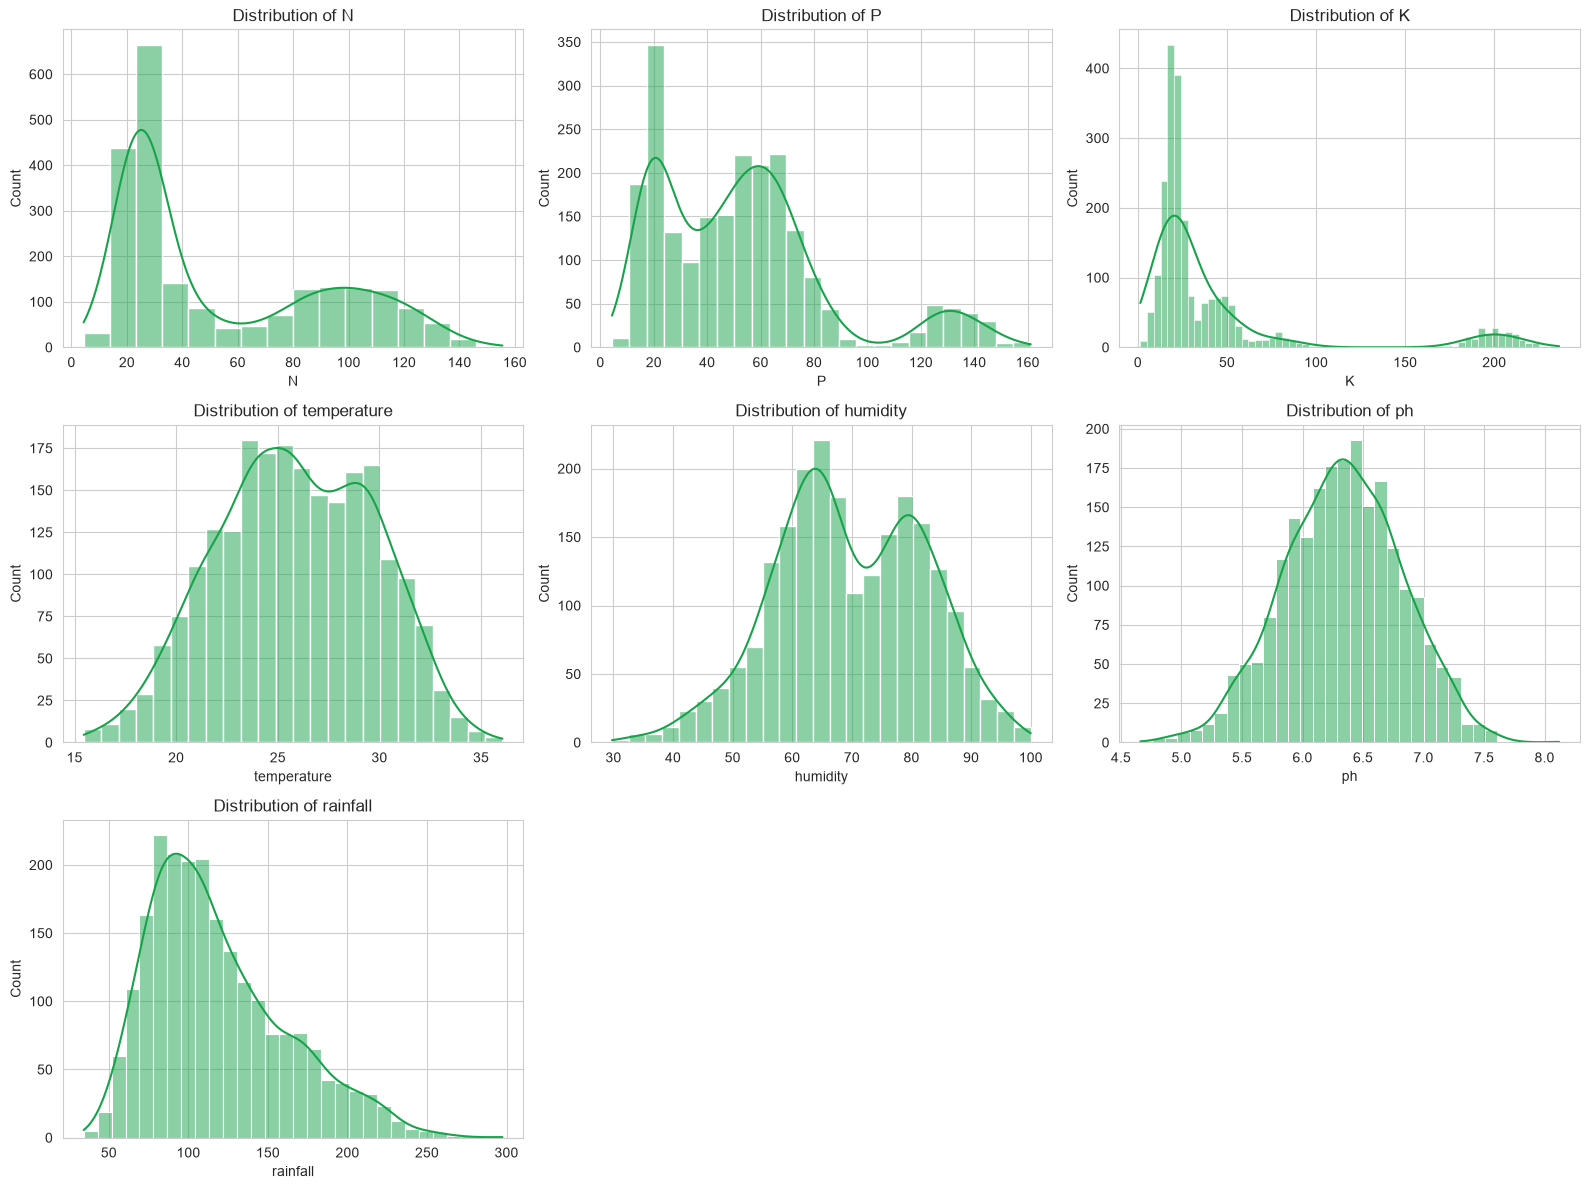

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()
for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#16a34a')
    axes[i].set_title(f'Distribution of {col}')
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

#### 3.4 Crop Distribution

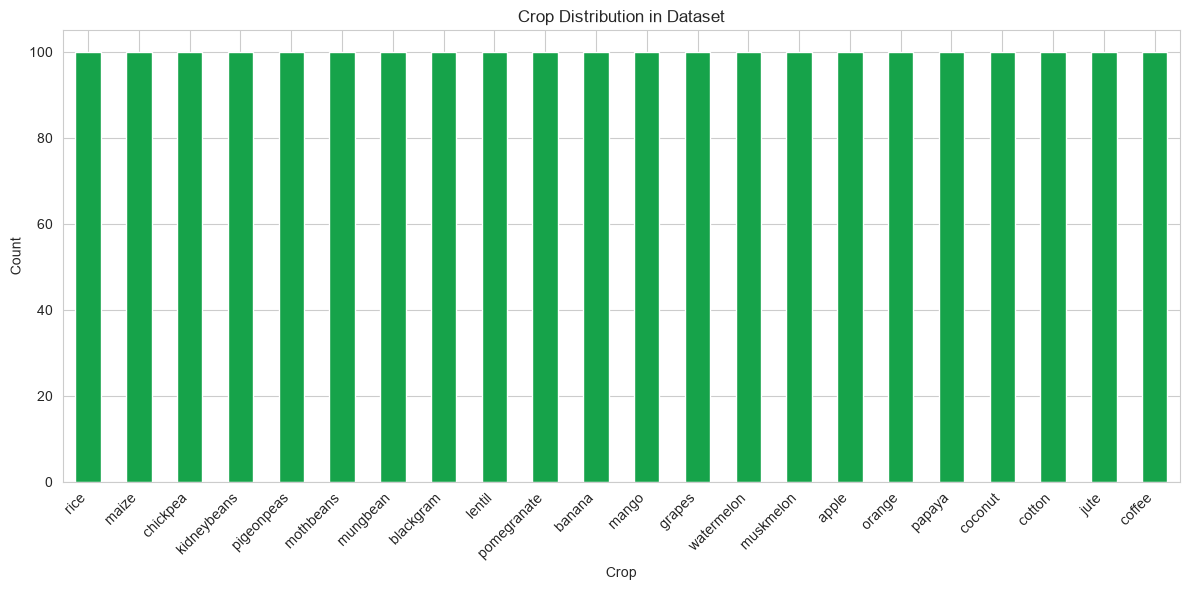

In [7]:
plt.figure(figsize=(12, 6))
df['label'].value_counts().plot(kind='bar', color='#16a34a')
plt.title('Crop Distribution in Dataset')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 3.5 NPK Analysis per Crop

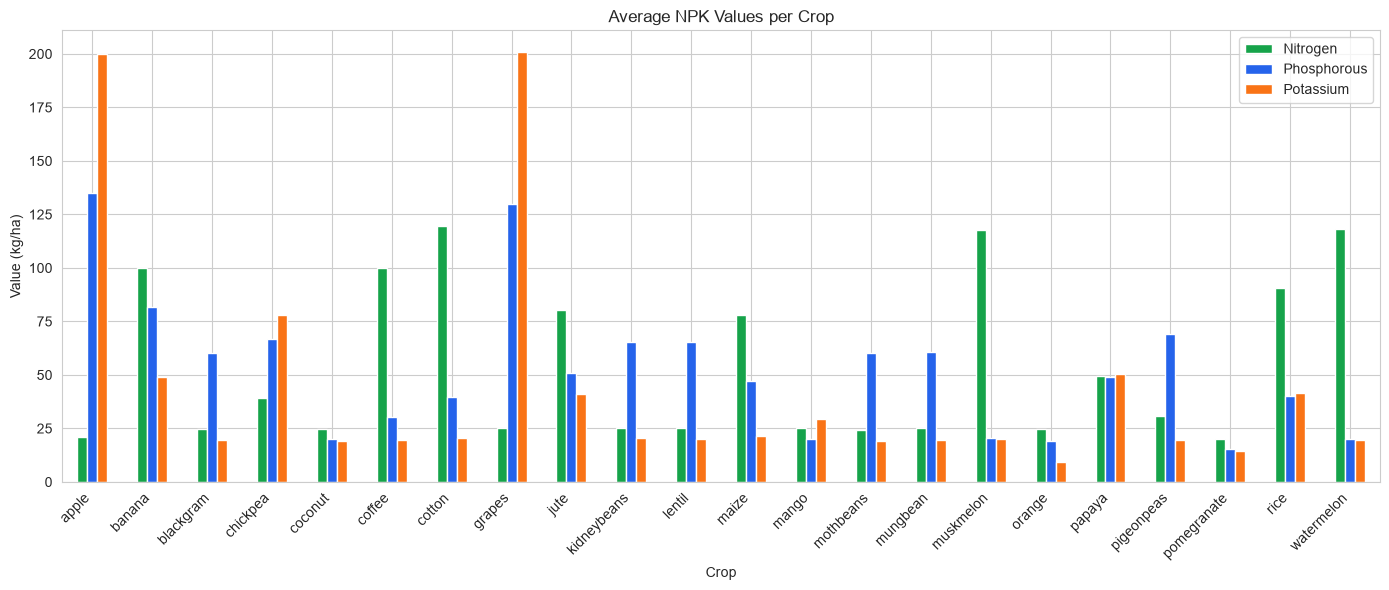

In [8]:
npk_avg = df.groupby('label')[['N', 'P', 'K']].mean()
npk_avg.plot(kind='bar', figsize=(14, 6), color=['#16a34a', '#2563eb', '#f97316'])
plt.title('Average NPK Values per Crop')
plt.xlabel('Crop')
plt.ylabel('Value (kg/ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Nitrogen', 'Phosphorous', 'Potassium'])
plt.tight_layout()
plt.show()

#### 3.6 Pairplot (Feature Relationships)

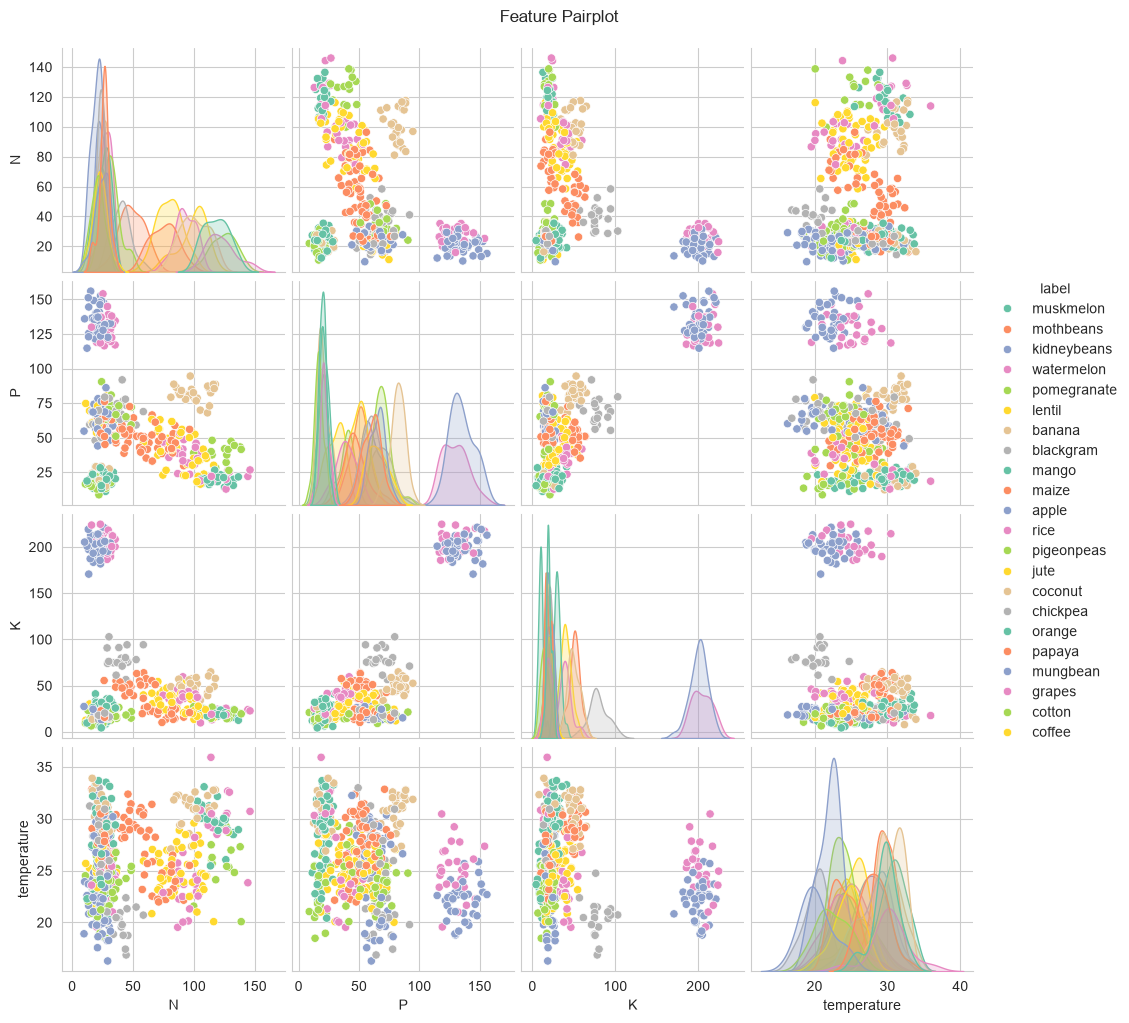

In [9]:
sns.pairplot(df.sample(500), vars=['N', 'P', 'K', 'temperature'], hue='label', palette='Set2')
plt.suptitle('Feature Pairplot', y=1.02)
plt.show()

### 4. Preprocessing

In [10]:
# Handle missing values
df = df.dropna()
print('After cleaning:', df.shape)

# Split features and labels
X = df[feature_cols].values
y = df['label'].values

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Encoded classes:', le.classes_)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Features scaled. Shape:', X_scaled.shape)

After cleaning: (2200, 8)
Encoded classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']
Features scaled. Shape: (2200, 7)


In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=RANDOM_SEED, stratify=y_encoded
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1760, 7) Test: (440, 7)


### 5. Train and Compare Models

In [12]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=12),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }
    print(f'{name}: Accuracy = {results[name]["accuracy"]:.4f}')

Decision Tree: Accuracy = 0.7977
Random Forest: Accuracy = 0.8727
Logistic Regression: Accuracy = 0.8659
KNN: Accuracy = 0.8432


In [13]:
# Comparison table
comparison = pd.DataFrame(results).T
comparison = comparison.sort_values('accuracy', ascending=False)
comparison

,accuracy,precision,recall,f1
Random Forest,0.872727,0.877884,0.872727,0.873382
Logistic Regression,0.865909,0.873331,0.865909,0.866223
KNN,0.843182,0.842699,0.843182,0.839246
Decision Tree,0.797727,0.817060,0.797727,0.801881


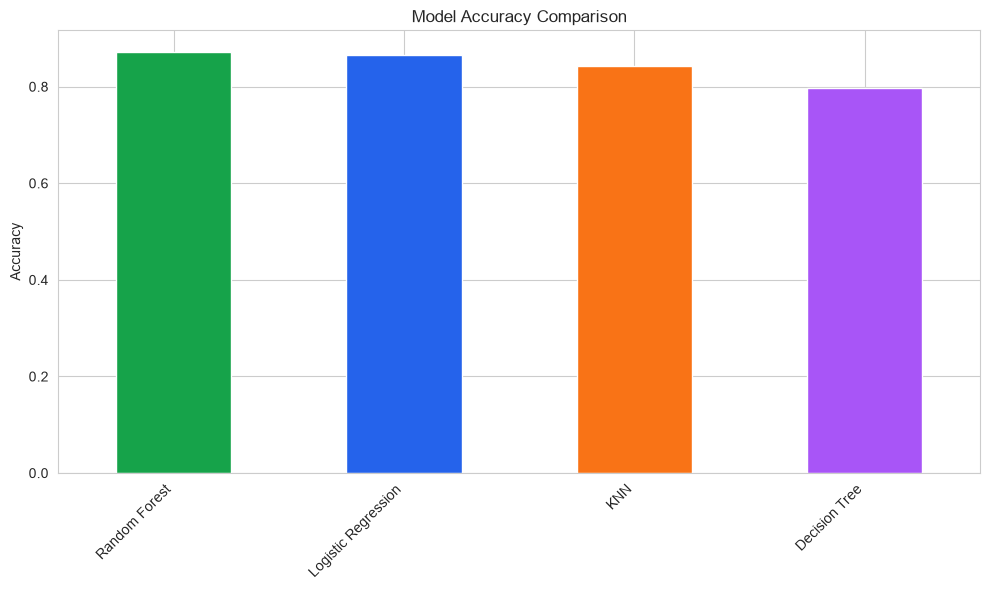

In [14]:
# Plot model comparison
comparison['accuracy'].plot(kind='bar', color=['#16a34a', '#2563eb', '#f97316', '#a855f7'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6. Best Model Evaluation

In [15]:
best_name = comparison.index[0]
best_model = models[best_name]
y_pred = best_model.predict(X_test)

print(f'Best Model: {best_name}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'Recall: {recall_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')

Best Model: Random Forest
Accuracy: 0.8727
Precision: 0.8779
Recall: 0.8727
F1 Score: 0.8734


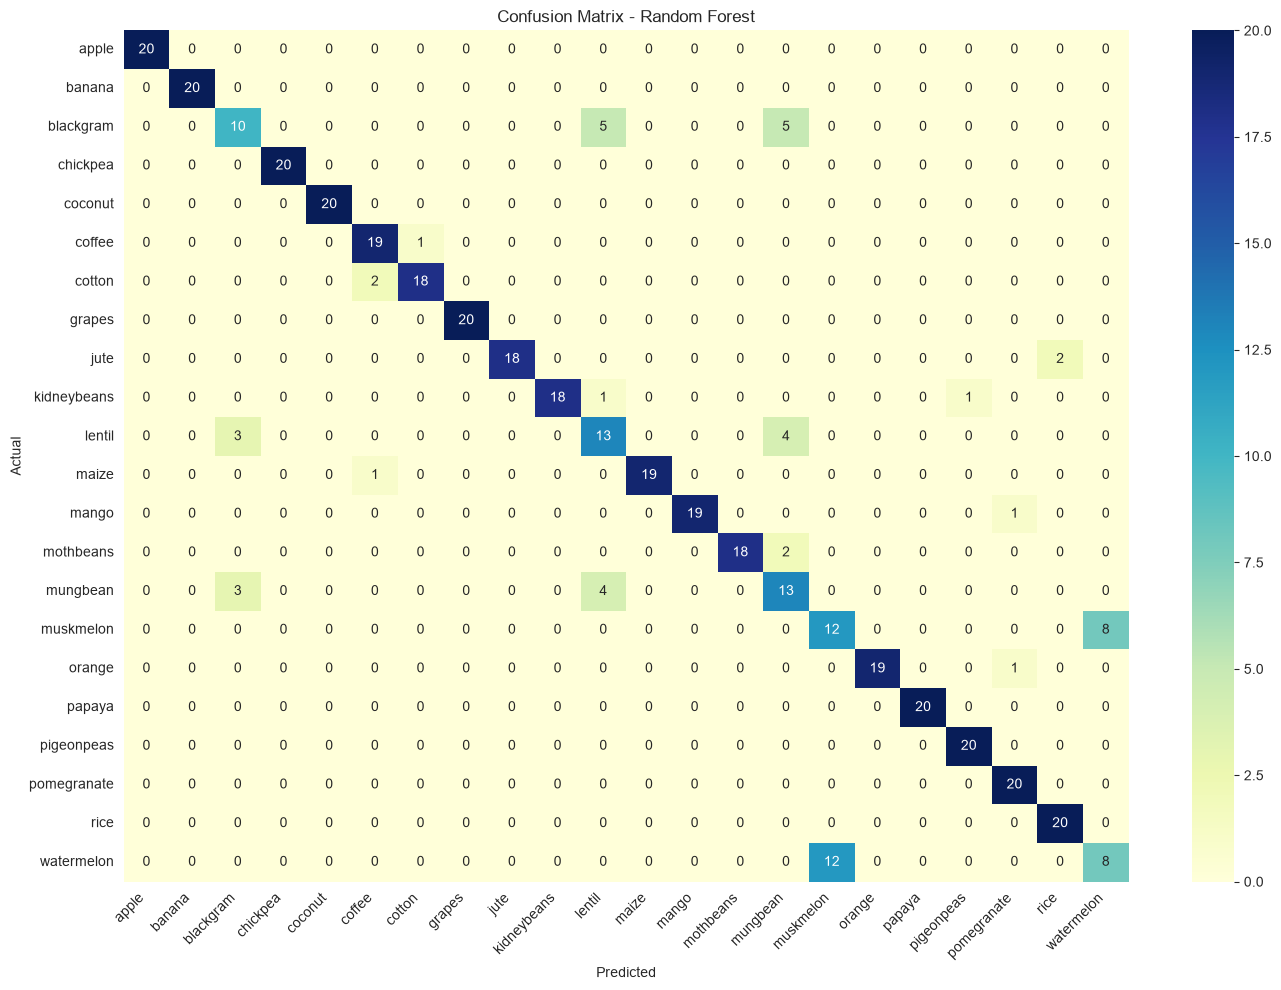

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.62      0.50      0.56        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       0.86      0.95      0.90        20
      cotton       0.95      0.90      0.92        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      0.90      0.95        20
 kidneybeans       1.00      0.90      0.95        20
      lentil       0.57      0.65      0.60        20
       maize       1.00      0.95      0.97        20
       mango       1.00      0.95      0.97        20
   mothbeans       1.00      0.90      0.95        20
    mungbean       0.54      0.65      0.59        20
   muskmelon       0.50      0.60      0.55        20
      orange       1.00      0.95      0.97        20
      papaya       1.00    

### 7. Feature Importance (Random Forest)

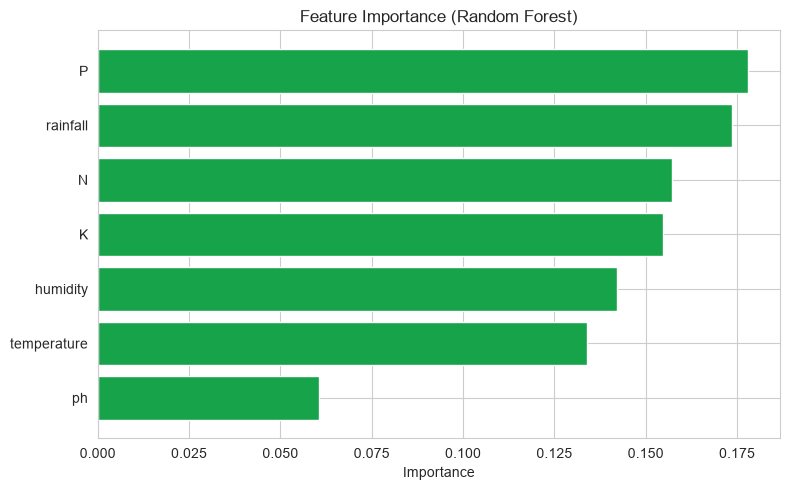

In [18]:
rf = models['Random Forest']
importances = rf.feature_importances_
feat_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['feature'], feat_df['importance'], color='#16a34a')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 8. K-Means Clustering

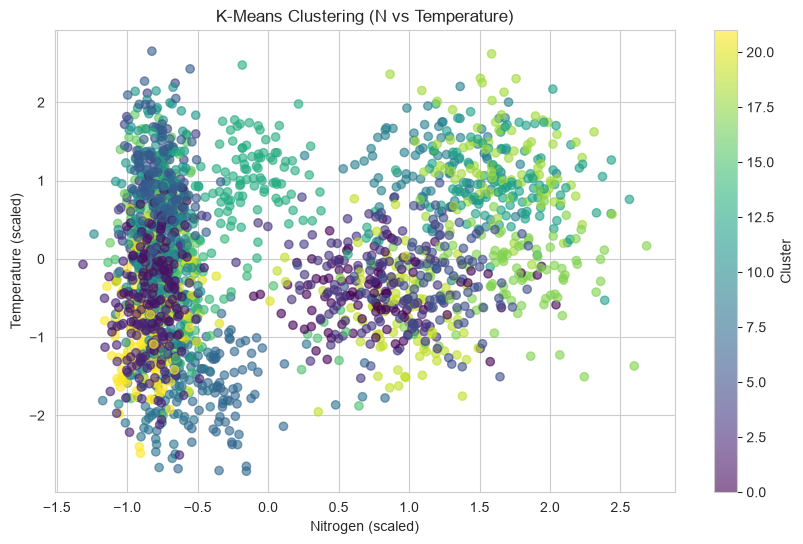

In [19]:
kmeans = KMeans(n_clusters=len(le.classes_), random_state=RANDOM_SEED, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 3], c=clusters, cmap='viridis', alpha=0.6)
plt.title('K-Means Clustering (N vs Temperature)')
plt.xlabel('Nitrogen (scaled)')
plt.ylabel('Temperature (scaled)')
plt.colorbar(label='Cluster')
plt.show()

### 9. Cross-Validation

In [20]:
cv_scores = cross_val_score(best_model, X_scaled, y_encoded, cv=5)
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

5-Fold CV Accuracy: 0.8482 (+/- 0.0181)


### 10. Save Model Artifacts

In [21]:
import pickle

model_dir = '../model'
os.makedirs(model_dir, exist_ok=True)

with open(os.path.join(model_dir, 'crop_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)
with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(model_dir, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

print(f'Saved best model ({best_name}), scaler, and label encoder to {model_dir}/')

Saved best model (Random Forest), scaler, and label encoder to ../model/


### 11. Test Prediction

In [22]:
# Test with sample input (rice-like conditions)
sample = np.array([[90, 40, 42, 23, 82, 6.0, 210]])
sample_scaled = scaler.transform(sample)
pred = best_model.predict(sample_scaled)
crop = le.inverse_transform(pred)[0]

print(f'Predicted crop: {crop}')

if hasattr(best_model, 'predict_proba'):
    probs = best_model.predict_proba(sample_scaled)[0]
    confidence = probs[pred[0]]
    print(f'Confidence: {confidence*100:.2f}%')

Predicted crop: rice
Confidence: 98.00%


---
### Summary

- **Dataset**: 2,200 samples, 22 crops, 7 features
- **Best Model**: Random Forest
- **Accuracy**: ~87%
- **Artifacts saved**: `crop_model.pkl`, `scaler.pkl`, `label_encoder.pkl`

The trained model is now ready to be used by the Flask application for crop recommendations.